In [27]:
import numpy as np
import matplotlib.pyplot as plt
from psf_toolbox_v2 import psf_high_NA_vector, render_psf_emitters

au = 580*0.61/1.4 # airy unit

psfhr_x, x, y = psf_high_NA_vector(256, 8, 0.580, 1.4, 1.5, 'x', A_def = 0, A_ast=0)
psfhr_y, x, y = psf_high_NA_vector(256, 8, 0.580, 1.4, 1.5, 'y', A_def = 0, A_ast=0)
psfhr = (psfhr_x + psfhr_y)*0.5
psfhr = psfhr[1024-32 : 1024+32, 1024-32: 1024+32]

-1 24.22577386094251


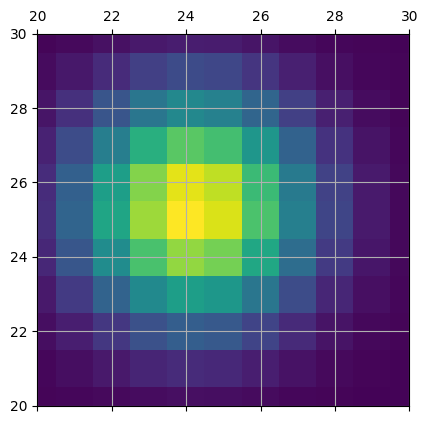

-0.75 24.7696779433837


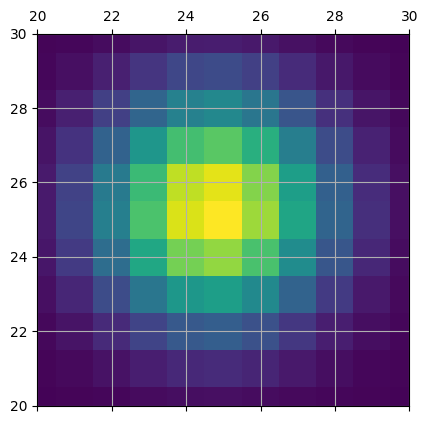

-0.5 24.7696779433837


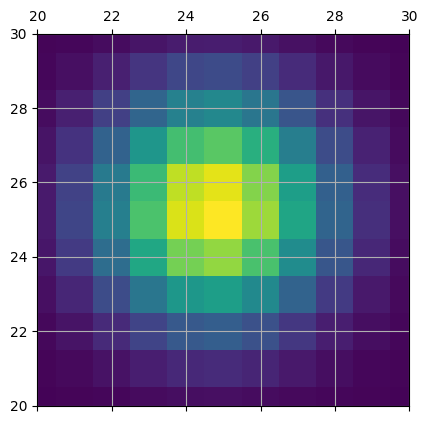

-0.25 25.313537527959824


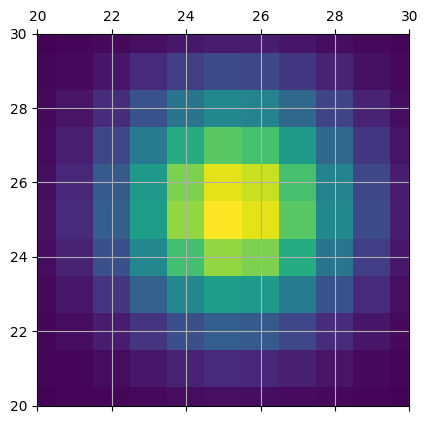

0 25.313537527959824


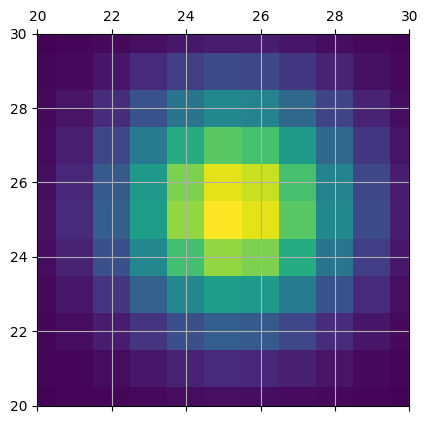

0.25 25.857056585206777


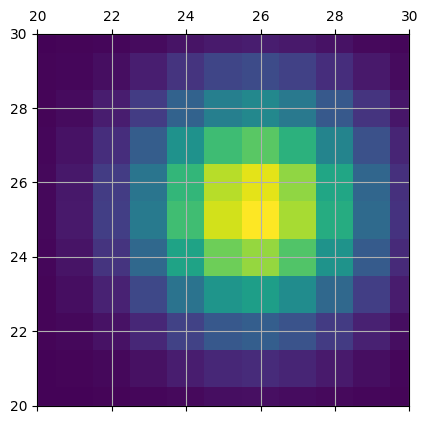

0.5 25.857056585206777


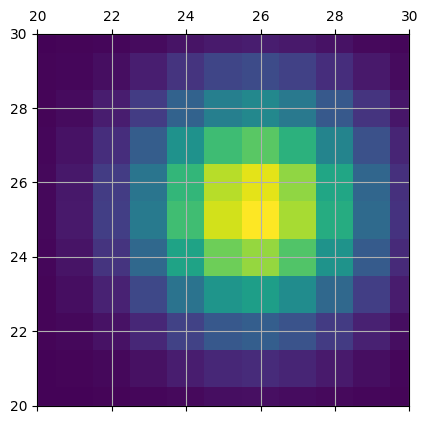

0.75 26.39332496783352


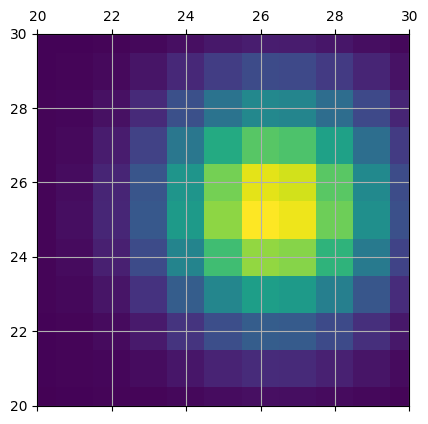

1 26.39332496783352


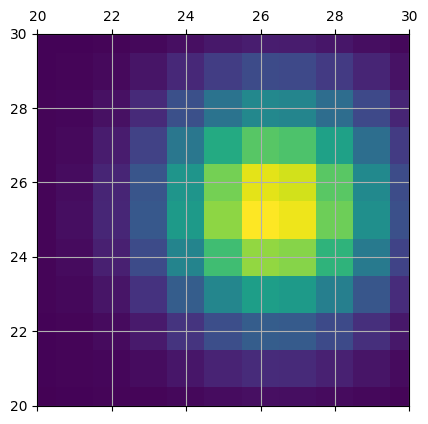

In [3]:
for dx in [-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1]:
    xyi = np.array([
        (25+dx,25,1),
    ])
    au = 580*0.61/1.4 #airy unit
    im = render_psf_emitters(xyi, 59/au, psfhr, 0.125, 50, 50)
    im = (im-np.min(im))
    im /= np.sum(im)
    centroid_x = np.sum(im, axis=0)
    _x = np.arange(len(centroid_x))
    mu = (_x @ centroid_x)/np.sum(centroid_x)
    print(dx, mu)
    
    plt.matshow(im)
    plt.xlim(20,30)
    plt.ylim(20,30)
    plt.grid()
    plt.show()

In [4]:
## Even higher res

psfhr_x, x, y = psf_high_NA_vector(256, 16, 0.580, 1.4, 1.5, 'x', A_def = 0, A_ast=0)
psfhr_y, x, y = psf_high_NA_vector(256, 16, 0.580, 1.4, 1.5, 'y', A_def = 0, A_ast=0)
psfhr = (psfhr_x + psfhr_y)*0.5
psfhr = psfhr[2*1024-32*2 : 2*1024+2*32, 2*1024-2*32: 2*1024+2*32]



(48.0, 80.0)

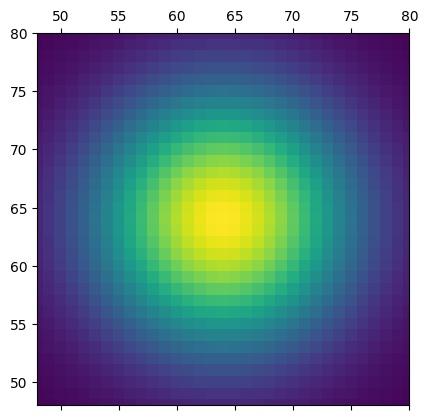

In [5]:
plt.matshow(psfhr)
plt.xlim(64-16,64+16)
plt.ylim(64-16,64+16)

-1 23.824977891283016


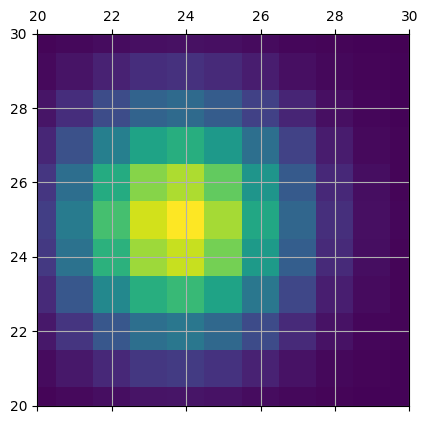

-0.75 24.095761181198498


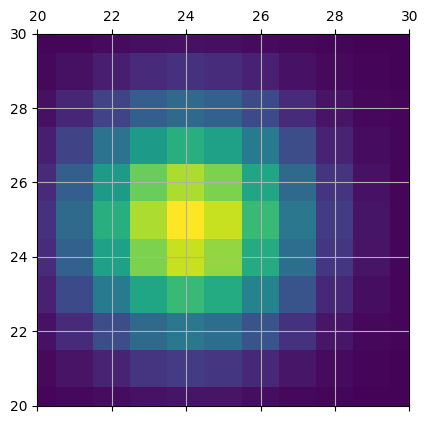

-0.5 24.365147033506872


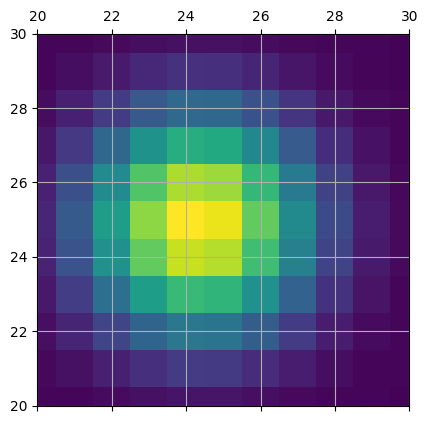

-0.25 24.632621609528083


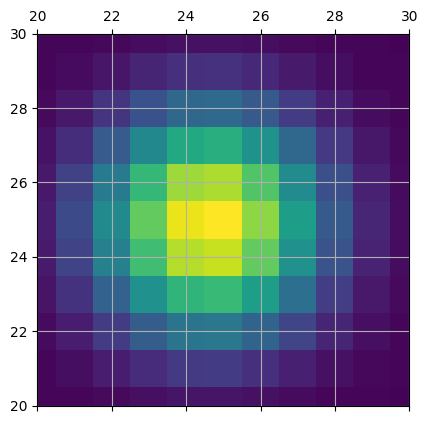

0 24.90128928256108


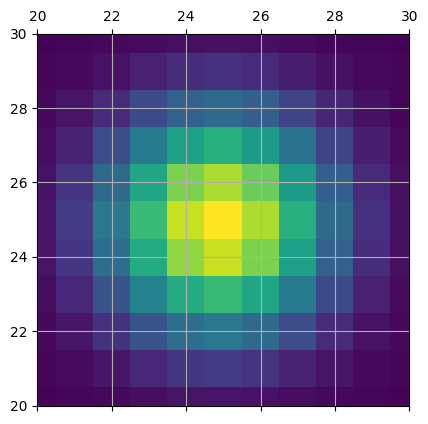

0.25 25.171090995789065


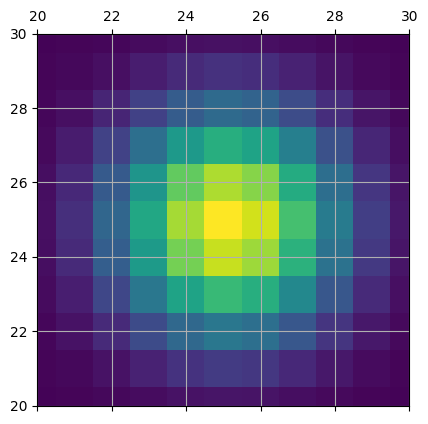

0.5 25.441273876882534


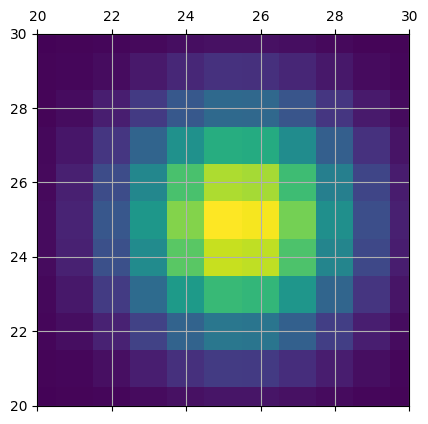

0.75 25.701076580922965


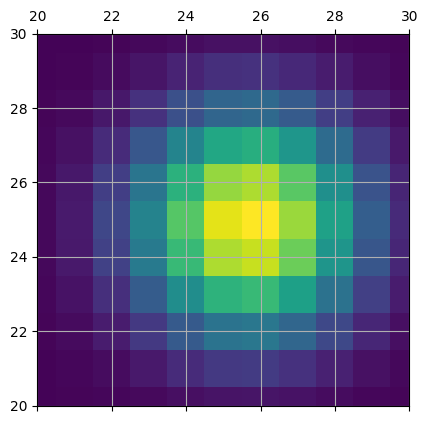

1 25.9775081009923


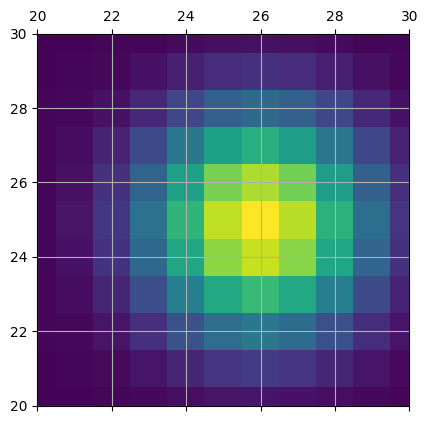

In [7]:
images = []
for dx in [-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1]:
    xyi = np.array([
        (25+dx,25,1),
    ])
    au = 580*0.61/1.4 #airy unit
    im = render_psf_emitters(xyi, 59/au, psfhr, 0.125/2, 50, 50)
    im = (im-np.min(im))
    im /= np.sum(im)
    images.append(im)
    centroid_x = np.sum(im, axis=0)
    _x = np.arange(len(centroid_x))
    mu = (_x @ centroid_x)/np.sum(centroid_x)
    print(dx, mu)
    
    plt.matshow(im)
    plt.xlim(20,30)
    plt.ylim(20,30)
    plt.grid()
    plt.show()

images = np.array(images)

In [8]:
np.save('new_psfs_in.npy', images)

In [9]:
imgout = np.load('new_psfs_out.npy')

In [19]:
for dx in [-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1]:
    x = 25+dx
    print(4*x + 1.5)

97.5
98.5
99.5
100.5
101.5
102.5
103.5
104.5
105.5


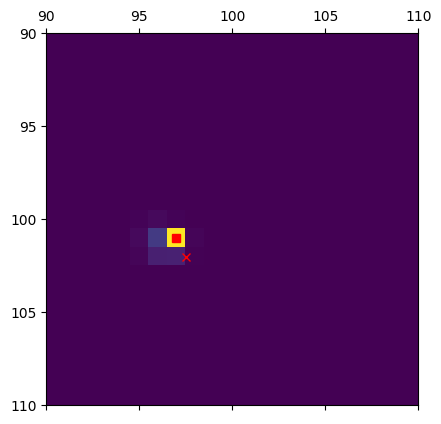

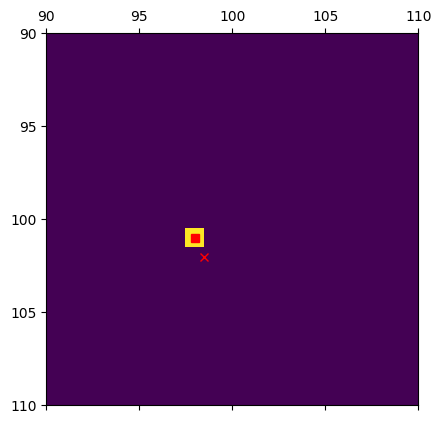

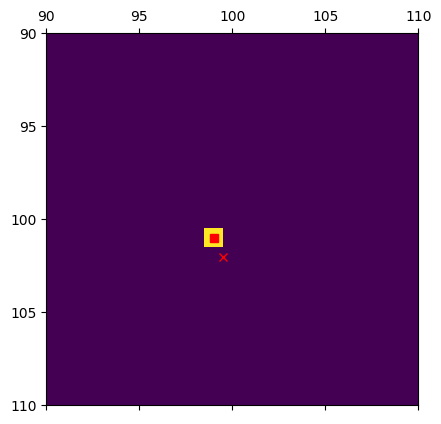

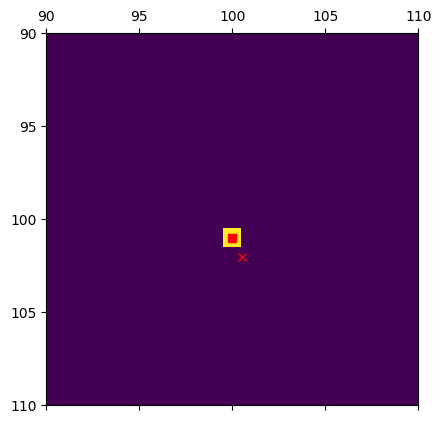

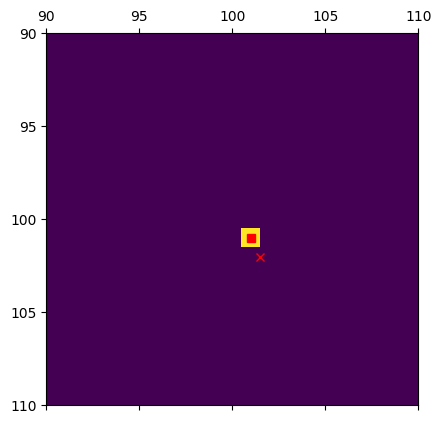

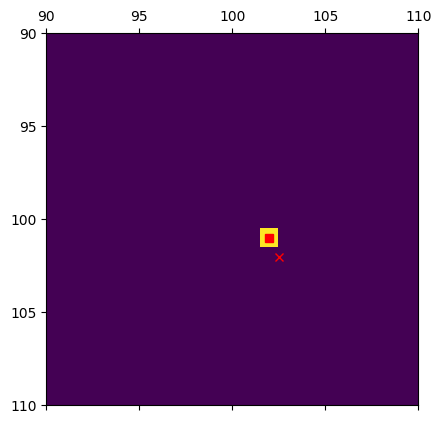

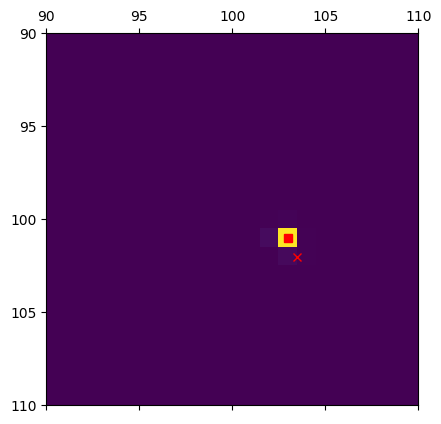

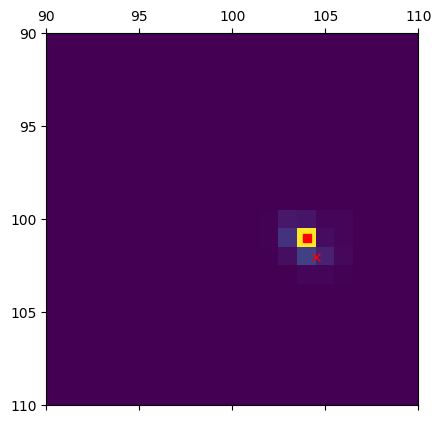

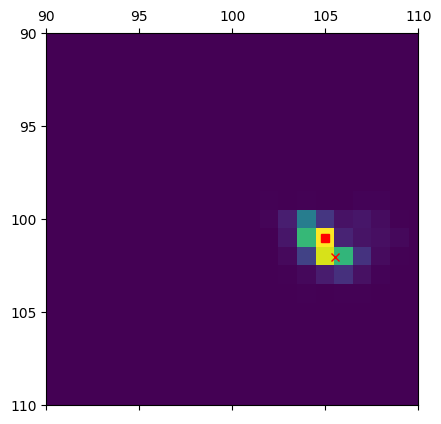

In [26]:
dxs = [-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1]
for i, dx in enumerate(dxs):
    x = 25+dx
    xup = x*4 + 1.5
    xup2 = x*4 + 1
    yup2 = 25*4 + 1
    plt.matshow(imgout[i])
    plt.plot([xup], [102], "rx")
    plt.plot([xup2], [yup2], "rs")
    plt.xlim(90,110)
    plt.ylim(110,90)
    plt.show()